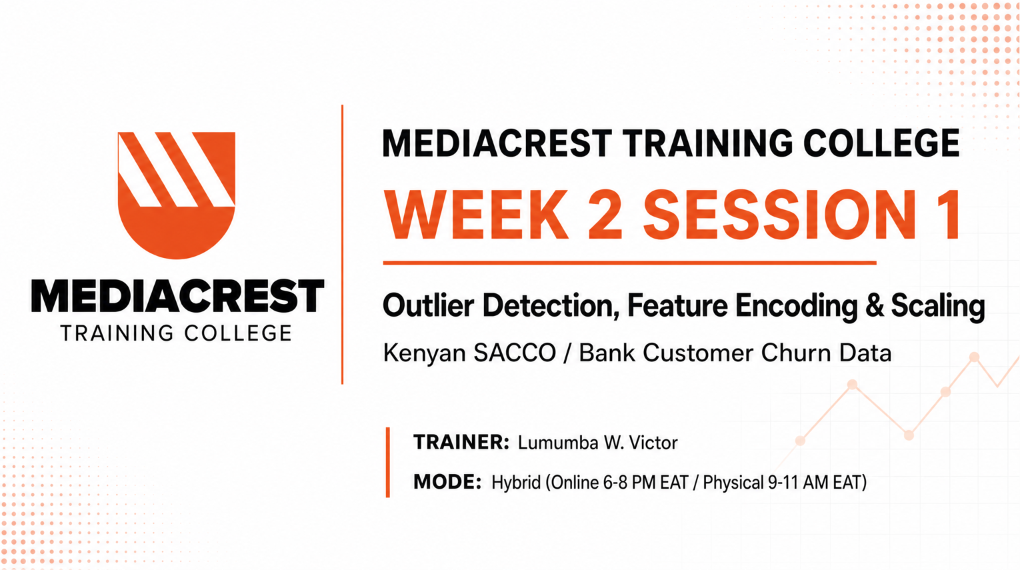

### **LOAD THE REQUIRED LIBRARIES**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### **1. DATA LOADING & INITIAL PROFILING**
The attached CSV has no header row, so we assign logical column names based on standard Kenyan banking/SACCO churn schemas

In [23]:
columns = [
    'CustomerID', 'Age', 'Gender', 'MaritalStatus', 'Education', 
    'EmploymentStatus', 'Tenure', 'AccountType', 'NumProducts', 'Balance', 
    'SaccoScore', 'MonthsInactive', 'BranchVisits', 'IsStudent', 'UtilizationRate', 
    'HasCrCard', 'HasLoan', 'IsMobile', 'IsInternet', 'Churn'
]

### **LOAD THE DATA SET**

In [24]:
df = pd.read_csv('churn_data.csv', header=None, names=columns)
df.head()

,CustomerID,Age,Gender,MaritalStatus,Education,EmploymentStatus,Tenure,AccountType,NumProducts,Balance,SaccoScore,MonthsInactive,BranchVisits,IsStudent,UtilizationRate,HasCrCard,HasLoan,IsMobile,IsInternet,Churn
0,CUST2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,CUST2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,CUST2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,CUST0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,CUST0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        10000 non-null  object 
 1   Age               10000 non-null  int64  
 2   Gender            10000 non-null  object 
 3   MaritalStatus     10000 non-null  object 
 4   Education         8974 non-null   object 
 5   EmploymentStatus  10000 non-null  object 
 6   Tenure            10000 non-null  int64  
 7   AccountType       10000 non-null  object 
 8   NumProducts       10000 non-null  int64  
 9   Balance           10000 non-null  int64  
 10  SaccoScore        10000 non-null  int64  
 11  MonthsInactive    10000 non-null  int64  
 12  BranchVisits      10000 non-null  int64  
 13  IsStudent         10000 non-null  int64  
 14  UtilizationRate   10000 non-null  float64
 15  HasCrCard         10000 non-null  int64  
 16  HasLoan           10000 non-null  int64  

The purpose of this exercise is to demonstrate that **data preprocessing principles are transferable across different datasets and domains**. Although the Session 1 example used the MOH dataset, the same statistical and data-cleaning concepts apply to the Kenyan SACCO/Bank Churn Dataset.

The dataset contains variables with different characteristics, including **financial balances, demographic information, categorical variables, and geographical information**. These differences provide a practical opportunity to apply the preprocessing techniques covered in Session 2.

**Key concepts to emphasize:**

* **Skewed numerical variables:** Financial variables such as account balances, income, or transaction amounts may have a long right tail. Transformations such as the logarithmic transformation can help reduce skewness and make the variables more suitable for statistical and machine-learning models.

* **High-cardinality categorical variables:** Variables such as *County* may contain many unique categories—in this case, potentially dozens of counties. Simply one-hot encoding every category can produce a large number of columns. We therefore need to consider appropriate encoding strategies depending on the modelling objective.

* **Data types and consistency:** Before modelling, categorical, numerical, date, and identifier variables should be correctly identified. Incorrect data types can cause errors during analysis and modelling.

* **Missing values and unusual observations:** Preprocessing should also identify missing values, duplicates, impossible values, and potential outliers before the modelling stage.

The **dataset may change, but the preprocessing logic does not**. Whether we are analysing healthcare data, SACCO customers, bank customers, or business transactions, we follow the same general workflow:

**Inspect → Identify data-quality issues → Clean → Transform → Encode → Validate → Model**

The goal is not simply to clean this particular dataset, but to develop a **general preprocessing mindset** that learners can apply to datasets from different industries.


### **2. OUTLIER DETECTION (0:10 - 0:35)**

#### **A. Visual Detection (Boxplots)**

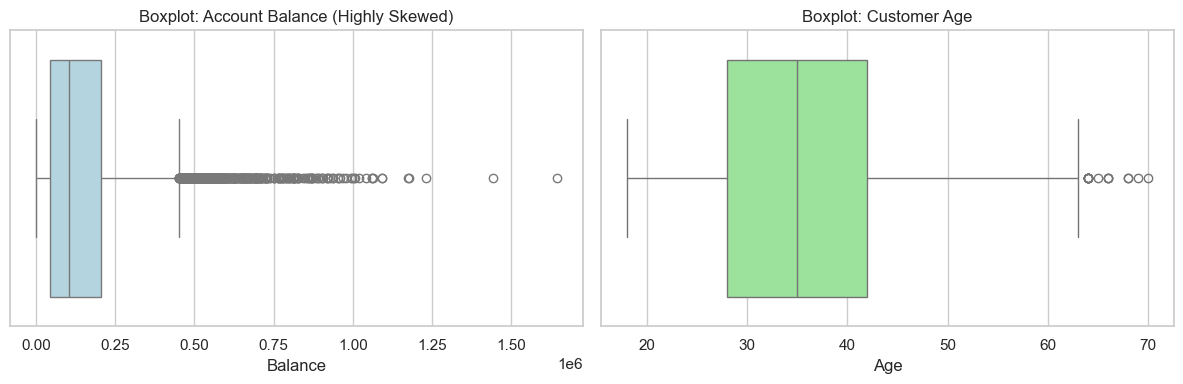

In [26]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Balance'], color='lightblue')
plt.title('Boxplot: Account Balance (Highly Skewed)')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title('Boxplot: Customer Age')
plt.tight_layout()
plt.show()

#### **B. Statistical Detection (IQR & Z-Score)**

In [27]:
print("\n--- B. Statistical Detection (Balance) ---")
Q1 = df['Balance'].quantile(0.25)
Q3 = df['Balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Balance'] < lower_bound) | (df['Balance'] > upper_bound)]
print(f"IQR Method: Found {len(outliers_iqr)} outliers (outside {lower_bound:.0f} to {upper_bound:.0f}).")


--- B. Statistical Detection (Balance) ---
IQR Method: Found 503 outliers (outside -199286 to 450070).


In [28]:
z_scores = np.abs(stats.zscore(df['Balance'].dropna()))
outliers_z = df['Balance'][z_scores > 3]
print(f"Z-Score Method: Found {len(outliers_z)} outliers (Z > 3).")

Z-Score Method: Found 177 outliers (Z > 3).


### **3. OUTLIER TREATMENT DECISIONS (0:35 - 0:55)**
#### **Trainer Notes: Outlier Treatment in Kenyan Financial Data**

Outliers should **not automatically be treated as errors**. In financial datasets, extremely large values may represent genuine customers, businesses, or transactions rather than data-entry mistakes.

For example, a SACCO member with a very large savings balance may be a **high-net-worth individual, an SME, or an institutional customer**. Removing such observations simply because they are statistically unusual could lead to **selection bias** and cause the model to underrepresent important customer segments.

Instead of deleting valid extreme observations, we can use **capping (Winsorization)**. This limits the influence of extreme values while retaining the observation in the dataset.

**Trainer emphasis:**

> *An outlier is not necessarily an error. Before removing an extreme observation, ask: “Is this value impossible, or is it simply unusual?”*

A useful decision framework is:

* **Data-entry error →** Correct or remove it.
* **Impossible value →** Investigate and correct/remove.
* **Valid but extreme value →** Retain, but consider capping or transformation.
* **Business-critical extreme value →** Retain and carefully assess its influence.

The key lesson is that **outlier treatment should be guided by statistical evidence and domain knowledge**, not by an arbitrary rule such as “delete everything beyond the 95th percentile.”


#### **Treatment: Capping at 95th Percentile**

In [29]:
cap_val = df['Balance'].quantile(0.95)
df['Balance_Capped'] = df['Balance'].clip(upper=cap_val)

In [30]:
cap_val = df['Age'].quantile(0.95)
df['Age_Capped'] = df['Age'].clip(upper=cap_val)

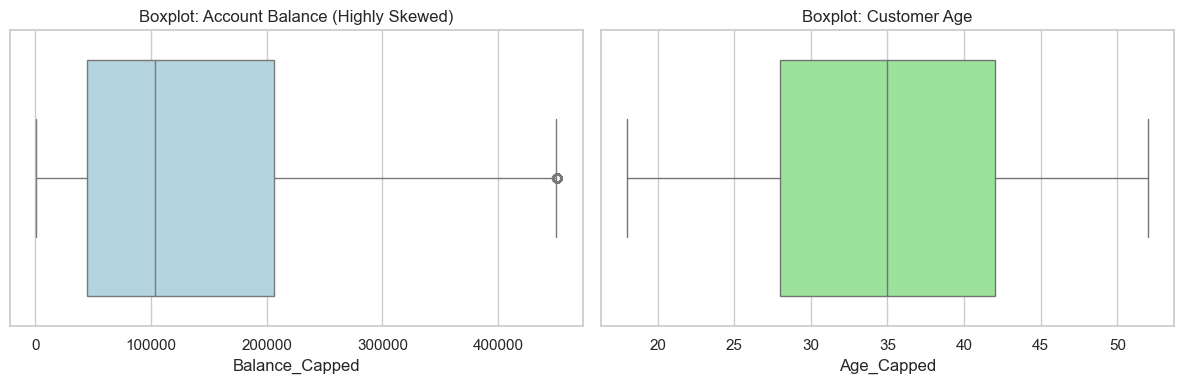

In [31]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Balance_Capped'], color='lightblue')
plt.title('Boxplot: Account Balance (Highly Skewed)')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age_Capped'], color='lightgreen')
plt.title('Boxplot: Customer Age')
plt.tight_layout()
plt.show()

Here, we cap the **Balance** variable at its 95th percentile. This means that observations above the calculated threshold are not deleted; instead, their values are replaced with the **95th-percentile value**.

For example, if the 95th percentile is **500,000 KES**, a customer with a balance of 1,200,000 KES will have the balance treated as 500,000 KES for the analysis.

This approach has two main advantages:

* **Preserves the sample size:** No customers are removed from the dataset.
* **Reduces the influence of extreme values:** Very large balances are prevented from dominating calculations and distance-based algorithms such as **KNN and clustering**.

> **Trainer emphasis:** Capping does not mean that the original value was wrong. It is a modelling strategy used to reduce the disproportionate influence of extreme observations.

**Important:** The 95th percentile is a practical choice, not a universal rule. The appropriate threshold should depend on the **distribution of the variable, the research objective, and the business context**.


### **4. FEATURE ENCODING STRATEGIES (1:05 - 1:25)**

#### **A. Ordinal Encoding (Preserving Hierarchy)**

In [32]:
edu_map = {'None': 0, 'Primary': 1, 'Secondary': 2, 'University': 3}
df['Education_Ord'] = df['Education'].map(edu_map)
print("1. Ordinal Encoding applied to 'Education' (None < Primary < Secondary < Univ).")

1. Ordinal Encoding applied to 'Education' (None < Primary < Secondary < Univ).


#### **B. One-Hot Encoding (Low Cardinality)**

In [33]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        10000 non-null  object 
 1   Age               10000 non-null  int64  
 2   Gender            10000 non-null  object 
 3   MaritalStatus     10000 non-null  object 
 4   Education         8974 non-null   object 
 5   EmploymentStatus  10000 non-null  object 
 6   Tenure            10000 non-null  int64  
 7   AccountType       10000 non-null  object 
 8   NumProducts       10000 non-null  int64  
 9   Balance           10000 non-null  int64  
 10  SaccoScore        10000 non-null  int64  
 11  MonthsInactive    10000 non-null  int64  
 12  BranchVisits      10000 non-null  int64  
 13  IsStudent         10000 non-null  int64  
 14  UtilizationRate   10000 non-null  float64
 15  HasCrCard         10000 non-null  int64  
 16  HasLoan           10000 non-null  int64  

In [35]:
df = pd.get_dummies(df, columns=['Gender', 'MaritalStatus'], 
                    drop_first=True, 
                    dtype=int)
print("2. One-Hot Encoding applied to 'Gender' and 'MaritalStatus'.")
df.head()

2. One-Hot Encoding applied to 'Gender' and 'MaritalStatus'.


,CustomerID,Age,Education,EmploymentStatus,Tenure,AccountType,NumProducts,Balance,SaccoScore,MonthsInactive,...,HasLoan,IsMobile,IsInternet,Churn,Balance_Capped,Age_Capped,Education_Ord,Gender_Male,MaritalStatus_Married,MaritalStatus_Single
0,CUST2463,32,Primary,Employed,13,Current,2,57001,19,6,...,1,0,0,1,57001.0,32,1.0,1,0,0
1,CUST2511,45,University,Employed,88,Current,1,24533,14,5,...,1,0,0,0,24533.0,45,3.0,1,0,1
2,CUST2227,29,Primary,Employed,151,Savings,3,212133,16,11,...,1,0,0,0,212133.0,29,1.0,0,0,1
3,CUST0526,49,Secondary,Employed,118,Savings,2,94045,22,12,...,1,0,0,0,94045.0,49,2.0,0,0,1
4,CUST0195,33,Primary,Employed,108,Savings,1,137693,15,7,...,0,0,0,0,137693.0,33,1.0,0,0,1


#### **C. Target Encoding (Preventing Leakage & Handling High Cardinality)**

**Target Encoding** is useful when a categorical variable has many unique categories. Instead of creating a separate dummy variable for every category, we replace each category with a numerical value based on its relationship with the target variable.

For example, if we had a **County** variable containing Kenya's 47 counties, One-Hot Encoding could create **47 additional columns**. Target Encoding can instead represent each county using its **historical churn rate**.

For example:

| County  | Historical Churn Rate |
| ------- | --------------------: |
| Nairobi |                  0.32 |
| Mombasa |                  0.27 |
| Kisumu  |                  0.21 |

Thus, a customer from Nairobi could receive an encoded value of **0.32**.

**Why use K-Fold Target Encoding?**

A major risk with target encoding is **data leakage**. If we calculate the churn rate using the entire dataset—including the customer's own target value—we may give the model information it should not have during training.

K-Fold encoding reduces this risk by calculating the target statistic using **other folds of the training data**, rather than using the observation's own target information.

> **Trainer emphasis:** Target Encoding is particularly useful for **high-cardinality categorical variables**, but it must be implemented carefully to avoid **target leakage**.

In practice, always remember:

**High cardinality → Target Encoding can reduce dimensionality → K-Fold implementation helps prevent leakage.**


In [36]:
def kfold_target_encode(df, cat_col, target_col, n_splits=5):
    """Educational K-Fold Target Encoder to strictly prevent data leakage."""
    encoded_col = f"{cat_col}_TE"
    df = df.copy()
    df[encoded_col] = np.nan
    global_mean = df[target_col].mean()
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(df):
        fold_means = df.iloc[train_idx].groupby(cat_col)[target_col].mean()
        mapped = df.iloc[val_idx][cat_col].map(fold_means).fillna(global_mean)
        df.loc[df.index[val_idx], encoded_col] = mapped
    return df

df = kfold_target_encode(df, 'EmploymentStatus', 'Churn')
print("   -> Successfully encoded without leaking test-set information into training folds.")

   -> Successfully encoded without leaking test-set information into training folds.


#### **5. SCALING & STATISTICAL THINKING (1:25 - 1:45)**

##### **SCALING, NORMALIZATION & ALGORITHM SENSITIVITY**

In [37]:
# Comparing Scalers on the Capped Balance
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

In [38]:
print("\nScaling 'Balance_Capped' using three methods:")
for name, scaler in scalers.items():
    df[f'Balance_{name}'] = scaler.fit_transform(df[['Balance_Capped']])
    print(f"- {name}: Mean={df[f'Balance_{name}'].mean():.2f}, Std={df[f'Balance_{name}'].std():.2f}")


Scaling 'Balance_Capped' using three methods:
- StandardScaler: Mean=-0.00, Std=1.00
- MinMaxScaler: Mean=0.31, Std=0.28
- RobustScaler: Mean=0.24, Std=0.77


Different machine-learning algorithms respond differently to the **scale and distribution of predictor variables**. Therefore, scaling should not be treated as a routine step that is automatically applied to every dataset.

**1. Distance- and gradient-sensitive models**

Models such as **KNN, SVM, Logistic Regression, and Neural Networks** can be affected by differences in feature scales. For example, if one variable ranges from 0–1 while another ranges from 0–1,000, the larger-scale variable may have disproportionate influence.

For heavily skewed financial data, **RobustScaler** can be useful because it uses the **median and interquartile range (IQR)**, making it less sensitive to extreme observations.

**2. Tree-based models**

**Decision Trees, Random Forest, and XGBoost** generally do **not require feature scaling**. These algorithms make decisions using thresholds, such as:

> *Is Balance > 100,000 KES?*

rather than calculating distances between observations.

Therefore, scaling usually provides little or no benefit for these models.

**3. Important statistical clarification**

Be careful when discussing the **normality assumption**. StandardScaler itself does **not require normally distributed data**, and applying it to skewed data does not automatically violate a model assumption.

For **logistic regression**, for example, the normality of the predictors or residuals is **not a required assumption**. Scaling is primarily used to improve numerical stability, comparability of coefficients, and optimization.

> **Trainer emphasis:**
> **Scaling is algorithm-dependent.** Always ask *“Does this algorithm care about the scale of the predictors?”* rather than applying scaling automatically to every model.


#### **6. PRACTICAL APPLICATION & DELIVERABLE (1:45 - 2:00)**

##### **GENERATING FINAL DELIVERABLE & MEMO**

##### **Select final clean columns for the ML pipeline**

In [39]:

final_cols = [
    'Age', 'Tenure', 'NumProducts', 'SaccoScore', 'MonthsInactive', 'BranchVisits', 
    'UtilizationRate', 'Education_Ord', 'EmploymentStatus_TE', 'Balance_RobustScaler',
    'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Churn'
]
# Filter only existing columns
final_cols = [c for c in final_cols if c in df.columns]
df_final = df[final_cols].dropna()

In [40]:
output_file = 'churn_transformed_session2.csv'
df_final.to_csv(output_file, index=False)
print(f"\n[SUCCESS] Transformed dataset saved as '{output_file}'")


[SUCCESS] Transformed dataset saved as 'churn_transformed_session2.csv'


This section brings together the preprocessing decisions made during the session. The important point for learners is that **preprocessing choices should be justified rather than applied mechanically**. Each technique was selected based on the characteristics of the variable and the requirements of the modelling algorithm.

#### **1. Outlier Treatment — Winsorization/Capping**

We capped **Balance at the 95th percentile** rather than deleting observations.

In Kenyan financial data, an unusually large balance may represent a legitimate **high-net-worth customer, SME, or institutional account**. Therefore, statistical extremeness does not necessarily mean that the observation is erroneous.

Capping allows us to **retain the customer and preserve the sample size**, while reducing the influence of extreme balances on models that are sensitive to feature magnitude.

> **Trainer emphasis:** *Do not confuse an outlier with an error. Always investigate the business meaning of extreme observations before removing them.*

#### **2. Feature Encoding**

Different categorical variables require different encoding strategies.

**Education** was treated as an **ordinal variable** because its categories have a meaningful natural order. For example, primary → secondary → diploma → degree represents increasing educational attainment.

**Gender and MaritalStatus** were handled using **One-Hot Encoding** because they have relatively few categories and there is no meaningful numerical ranking between the categories.

For a variable such as **EmploymentStatus**, **Target Encoding using K-Fold** provides a way to represent categories using information related to the target while reducing the number of generated features.

This becomes particularly useful with **high-cardinality variables**. For example, a County variable with 47 counties could generate many additional dummy variables under One-Hot Encoding. Target Encoding can represent each county using its estimated historical churn rate instead.

The **K-Fold approach is important because it helps prevent target leakage** by ensuring that the target information used to encode an observation does not come directly from that observation.

#### **3. Scaling**

We selected **RobustScaler** for the Balance variable because financial variables often contain **skewness and extreme values**.

RobustScaler uses the **median and IQR**, rather than the mean and standard deviation. Consequently, it is less affected by unusually large observations.

This is particularly useful when preparing data for algorithms that are sensitive to feature scale, such as **KNN, SVM, and neural networks**.

> **Trainer emphasis:** *There is no single “best” preprocessing technique. The correct choice depends on the variable, the data distribution, and the algorithm being used.*

#### **Overall Takeaway**

The preprocessing pipeline follows a simple principle:

**Understand the data → identify the problem → select an appropriate transformation → justify the decision → validate the result.**

The objective is not merely to make the dataset “clean.” The objective is to produce **reliable, representative, and model-ready data without unnecessarily destroying useful information**.